In [ ]:
# Cell 1: Setup and imports
import mathviz
from mathviz import AlgebraVisualizer, CalculusVisualizer, MathViz
from mathviz import JupyterMathViz, JupyterSimpleMathViz
import matplotlib.pyplot as plt

# %matplotlib widget — needed for interactive matplotlib plots in Jupyter
%matplotlib widget

print(f"MathViz Version : {mathviz.get_info()['version']}")
print(f"Jupyter support : {mathviz.get_info()['jupyter_available']}")
print(f"JupyterSimple   : {JupyterSimpleMathViz is not None}")


Testing MathViz Version: 0.1.0


In [2]:
# Cell 2: Test the ipywidgets native integration
# You should see standard web-style sliders (not matplotlib sliders)
jv = JupyterMathViz()
jv.interactive_quadratic()

interactive(children=(FloatSlider(value=1.0, description='a', max=5.0, min=-5.0), FloatSlider(value=0.0, descr…

<function mathviz.jupyter_integration.JupyterMathViz.interactive_quadratic.<locals>.plot_quadratic(a=1.0, b=0.0, c=0.0)>

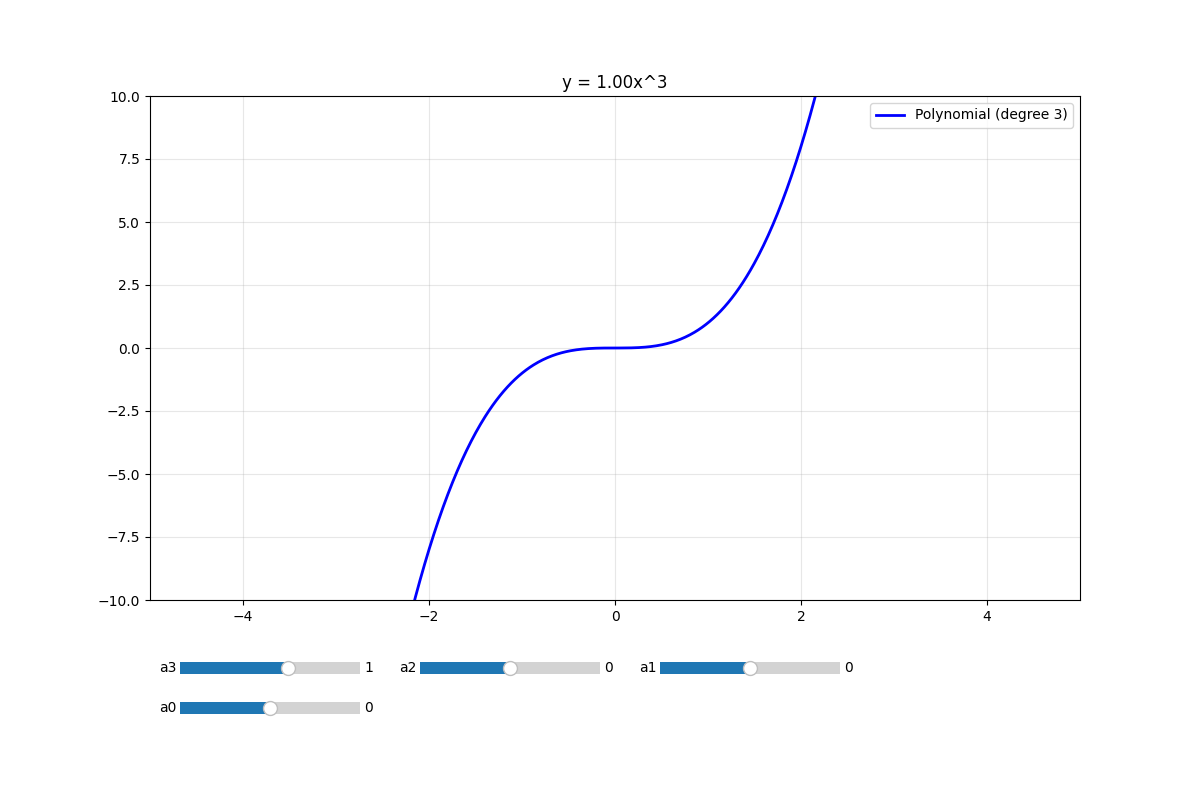

In [3]:
# Cell 3: Test standard MathViz UI components inside Jupyter
# You should see the custom matplotlib sliders you built in widgets.py
alg = AlgebraVisualizer()
fig1 = alg.polynomial_explorer(degree=3, x_range=(-5, 5))
plt.show()

## ⚠️ Text Input in Jupyter — Architecture Note

Matplotlib's native `TextBox` widget (used by `AlgebraVisualizer`, `CalculusVisualizer`, and `MathViz`) works perfectly in **standalone Python scripts**.

Inside a Jupyter Notebook, however, the `%matplotlib widget` (ipympl) backend often fails to capture keystrokes before they reach the notebook shell. Because Jupyter uses single-letter keyboard shortcuts in *Command Mode* (e.g. **`x`** cuts the cell, **`d`** deletes, **`b`** inserts below), typing a function like `sin(x)` into a Matplotlib `TextBox` can cause your cell to disappear.

### The fix: `JupyterSimpleMathViz`

`JupyterSimpleMathViz` replaces every `TextBox` with a native **`ipywidgets.Text`** box — a browser widget that correctly traps all keystrokes and never conflicts with Jupyter shortcuts.

| Environment | Correct class |
|---|---|
| Standalone script (`demo.py`) | `MathViz`, `AlgebraVisualizer`, `CalculusVisualizer` |
| Jupyter Notebook (text input) | `JupyterSimpleMathViz` |
| Jupyter Notebook (sliders only) | `JupyterMathViz` |


In [ ]:
# Cell 4: Derivative visualizer — Jupyter-native text input
# Type any function (sin(x), x**3 - 2*x, exp(-x**2), etc.) safely in the box below.
# The slider moves the tangent point.
jsv = JupyterSimpleMathViz()
jsv.interactive_derivative(initial_func="x**3", x_range=(-4, 4))


In [ ]:
# Cell 5: Integral visualizer — Jupyter-native text input
# Change the function, drag a/b sliders to adjust integration limits.
jsv2 = JupyterSimpleMathViz()
jsv2.interactive_integral(initial_func="sin(x)", x_range=(-4, 4))


In [ ]:
# Cell 6: Multi-function plotter (matplotlib backend)
# Sliders and hover tooltips work. Text-input boxes here work for symbols
# that don't clash with Jupyter shortcuts; use JupyterSimpleMathViz for safety.
core = MathViz()
fig3 = core.multi_function_plotter(["x**2", "x**3", "2*x"], x_range=(-3, 3))
plt.show()


## Summary — What works where

| Feature | Standalone script | Jupyter (matplotlib widget) | Jupyter (JupyterSimpleMathViz) |
|---|---|---|---|
| Sliders | ✅ | ✅ | ✅ |
| Hover tooltips (mplcursors) | ✅ | ✅ | ❌ (static redraws) |
| Text input — letters (x, s…) | ✅ | ⚠️ Keyboard conflict | ✅ |
| Text input — digits / symbols | ✅ | ✅ | ✅ |

**Rule of thumb:** use `JupyterSimpleMathViz` whenever you need a text box in Jupyter.

```python
from mathviz import JupyterSimpleMathViz
viz = JupyterSimpleMathViz()
viz.interactive_function_plotter()   # any expression: sin(x), x**3, exp(-x**2)
viz.interactive_derivative()
viz.interactive_integral()
viz.interactive_quadratic()
viz.interactive_parametric()
```
